In [ ]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
import warnings                                   # 검정 함수의 경고는 결론을 읽는 근거라 남긴다
warnings.simplefilter("ignore", FutureWarning)    # 버전 안내만 끈다
warnings.simplefilter("ignore", DeprecationWarning)
warnings.filterwarnings("ignore", "Glyph")        # 폰트에 없는 글자 안내

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다

import matplotlib.dates as mdates


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [2]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                 # 과제만 따로 열어도 이 셀만으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 하루 합계가 24개씩 묶인다는 뜻이 된다

ALPHA = 0.05                              # 유의수준 — 미션 2 와 같은 값을 씁니다
daily_c = df["count"].resample("D").sum()   # 쓸 변수 1 — 하루 합계로 만든 일 계열 (대/일)


def autocorr(x, k):                       # 쓸 변수 2 — 시차 k 자기상관 한 값
    """statsmodels acf 로 시차 0 부터 k 까지를 구한 뒤 k 번째 자리만 돌려줍니다"""
    return float(acf(np.asarray(x, dtype=float), nlags=k)[k])


_hour_profile = df.groupby(df.index.hour)["count"].mean()        # 쓸 변수 3 — 시각 프로파일 (대/시간)
_wday_profile = df.groupby(df.index.dayofweek)["count"].mean()   # 쓸 변수 4 — 요일 프로파일 (월=0 … 일=6)
_wday_name = ["월", "화", "수", "목", "금", "토", "일"]
_seas_strength = [1 - r.resid.var() / (r.seasonal + r.resid).var() for r in    # 쓸 변수 5 — 미션 1 과 같은 STL 두 번
         (STL(df["count"].astype(float), period=24, robust=True).fit(),
          STL(daily_c, period=7, robust=True).fit())]

print(f"일 계열 {len(daily_c):,}일  평균 {daily_c.mean():,.1f} 대/일  "
      f"표준편차 {daily_c.std():,.1f}")
print(f"시각 프로파일 : 최저 {_hour_profile.idxmin()}시 {_hour_profile.min():.1f} · "
      f"최고 {_hour_profile.idxmax()}시 {_hour_profile.max():,.1f} (대/시간) → {_hour_profile.max() / _hour_profile.min():.1f}배")
print(f"요일 프로파일 : 최저 {_wday_name[_wday_profile.idxmin()]} {_wday_profile.min():.1f} · "
      f"최고 {_wday_name[_wday_profile.idxmax()]} {_wday_profile.max():.1f} (대/시간) → "
      f"{_wday_profile.max() / _wday_profile.min():.2f}배")
print(f"미션 1 이 잰 계절 강도 : 주기 24 {_seas_strength[0]:.4f} (시간 계열 8,760시간)"
      f" · 주기 7 {_seas_strength[1]:.4f} (일 계열 365일)"
      "   (분모가 다른 두 계열이라 크고 작음만 비교합니다)")
print(f"유의수준 ALPHA = {ALPHA}")
print()
print("ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거")
print("KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거")
print("검정 도구 : adfuller(계열, autolag=\"AIC\") · kpss(계열, regression=\"c\", nlags=\"auto\")"
      " — 반환값의 첫 값이 통계량")
print("차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,")
print("            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다")
print("쓸 수 있는 이름 : df (표 전체) · daily_c (일 계열, 대/일) · ALPHA (유의수준)"
      " · autocorr(계열, 시차) · acf · adfuller · kpss")

일 계열 365일  평균 16,910.4 대/일  표준편차 10,258.6
시각 프로파일 : 최저 4시 132.6 · 최고 18시 1,502.9 (대/시간) → 11.3배
요일 프로파일 : 최저 일 625.2 · 최고 금 747.1 (대/시간) → 1.20배
미션 1 이 잰 계절 강도 : 주기 24 0.5715 (시간 계열 8,760시간) · 주기 7 0.0894 (일 계열 365일)   (분모가 다른 두 계열이라 크고 작음만 비교합니다)
유의수준 ALPHA = 0.05

ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거
KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거
검정 도구 : adfuller(계열, autolag="AIC") · kpss(계열, regression="c", nlags="auto") — 반환값의 첫 값이 통계량
차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,
            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다
쓸 수 있는 이름 : df (표 전체) · daily_c (일 계열, 대/일) · ALPHA (유의수준) · autocorr(계열, 시차) · acf · adfuller · kpss


C:\Users\tjwls\AppData\Local\Temp\ipykernel_24264\2048809271.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat_kpss0, p_kpss0 = kpss(daily_c, regression="c", nlags="auto")[:2]
C:\Users\tjwls\AppData\Local\Temp\ipykernel_24264\2048809271.py:37: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat_kpss1, p_kpss1 = kpss(d1, regression="c", nlags="auto")[:2]


일 계열 1차 차분 — 시차 1 자기상관 = -0.4953
일 계열 1차 차분 — 표준편차 = 8622.4 대/일
차분 전 일 계열 — KPSS 통계량 = 1.8375   → 정상 가설 기각 (비정상 쪽 증거)
차분 전 일 계열 — ADF 검정통계량 = -2.5966   → 단위근 가설 기각 못함 (비정상 쪽 증거)
1차 차분 일 계열 — KPSS 통계량 = 0.1023   → 정상 가설 기각 못함 (정상 쪽 증거)
1차 차분 일 계열 — ADF 검정통계량 = -13.6102   → 단위근 가설 기각 (정상 쪽 증거)
2차 차분 일 계열 — 표준편차와 시차 1 자기상관 = 14931.6 대/일, -0.6969


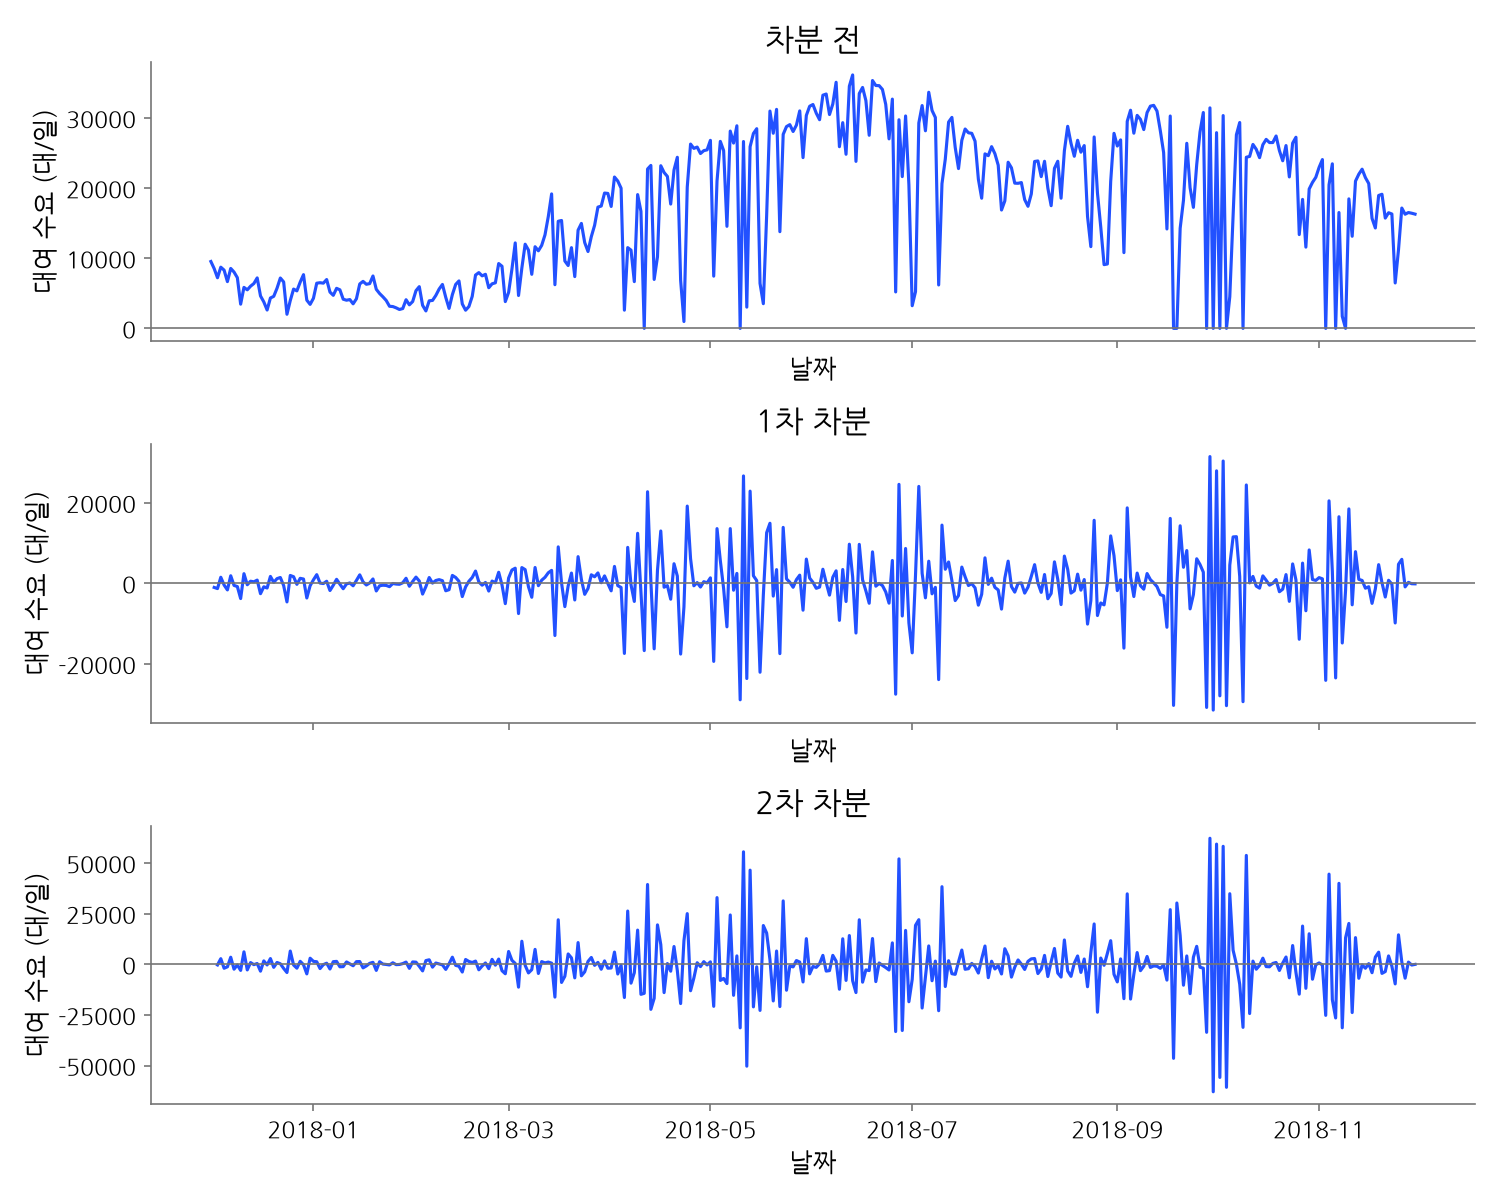

In [3]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
한 곳에서 아래 값 7개와 그림 한 장이 모두 출력되게 하고싶어. 
출력 행 이름 | 무엇	| 자릿수·단위	| 읽는 곳
일 계열 1차 차분 — 시차 1 자기상관 |	레벨 차분 1회 계열의 시차 1 자기상관 |	무차원 · 소수점 아래 4자리 · 양수에도 부호 표기 |	채점
일 계열 1차 차분 — 표준편차	| 같은 계열의 표준편차 |	대/일 · 소수점 아래 1자리	 | 채점
차분 전 일 계열 — KPSS 통계량	| 차분 전 일 계열에 적용한 반환값 첫 값 |	 무차원 · 소수점 아래 4자리 |	채점
1차 차분 일 계열 — KPSS 통계량 |	레벨 차분 1회 계열에 적용한 같은 값 |	무차원 · 소수점 아래 4자리 |	채점
차분 전 일 계열 — ADF 검정통계량 |	차분 전 일 계열에 적용한 반환값 첫 값 |	무차원 · 소수점 아래 4자리 |	브리핑 근거
1차 차분 일 계열 — ADF 검정통계량 |	레벨 차분 1회 계열에 적용한 같은 값 |	무차원 · 소수점 아래 4자리 |	브리핑 근거
2차 차분 일 계열 — 표준편차와 시차 1 자기상관	| 레벨 차분 2회 계열의 두 값을 한 행에 |	대/일 소수점 아래 1자리 · 자기상관 소수점 아래 4자리 |	루브릭

ADF 두 행은 같은 차분 단계의 KPSS 행 바로 다음에 적고, KPSS·ADF 네 행에는 「어느 가설을 기각했는가」 를 값과 같은 행에 함께 적습니다. 「읽는 곳」 이 채점인 네 값만 통과 여부를 정하고, 브리핑 근거 두 값은 위험 단락에, 루브릭 값은 과차분을 구분하는 데 씁니다.

그래프 한 장, 패널 3개 — 세 패널 모두 가로축은 날짜, 세로축은 대여 수요인 선 그래프
▸패널은 위에서부터 「차분 전」 · 「1차 차분」 · 「2차 차분」 이고 제목도 그대로 답니다
▸패널마다 계열 하나와 0 에 그은 가로선 하나를 두고, 가로축 이름은 「날짜」, 세로축 이름은 「대여 수요 (대/일)」 입니다

출력 형식 — 값을 굵은 이름 그대로 「이름 = 값 단위」 형태로 한 행씩 print 합니다. 값은 모두 daily_c 에서 계산하며, 휴무를 채운 보정 계열로 교체하면 수치가 달라져 통과하지 못합니다.


▸고정할 이름 — daily_c · ALPHA · autocorr 은 다시 만들지 마세요.
▸세 단계를 같은 형식으로 — 차분 전 · 1차 차분 · 2차 차분을 같은 순서로 출력하고 같은 순서로 배치해 그리세요.
▸출력과 그래프 — 값의 행 이름을 위의 굵은 이름 그대로 쓰고 단위·자릿수·부호를 지정하며, 패널 3개의 순서와 제목, 가로축·세로축 이름을 적을 것.

"""
# --- 여기부터 AI 코드 ---
d1 = daily_c.diff().dropna()
d2 = daily_c.diff().diff().dropna()

acf1_d1 = autocorr(d1, 1)
std_d1 = d1.std()

stat_kpss0, p_kpss0 = kpss(daily_c, regression="c", nlags="auto")[:2]
stat_adf0, p_adf0 = adfuller(daily_c, autolag="AIC")[:2]
stat_kpss1, p_kpss1 = kpss(d1, regression="c", nlags="auto")[:2]
stat_adf1, p_adf1 = adfuller(d1, autolag="AIC")[:2]

std_d2 = d2.std()
acf1_d2 = autocorr(d2, 1)

print(f"일 계열 1차 차분 — 시차 1 자기상관 = {acf1_d1:+.4f}")
print(f"일 계열 1차 차분 — 표준편차 = {std_d1:.1f} 대/일")

reject_kpss0 = p_kpss0 < ALPHA
print(f"차분 전 일 계열 — KPSS 통계량 = {stat_kpss0:.4f}   "
      f"→ 정상 가설 {'기각' if reject_kpss0 else '기각 못함'} "
      f"({'비정상' if reject_kpss0 else '정상'} 쪽 증거)")

reject_adf0 = p_adf0 < ALPHA
print(f"차분 전 일 계열 — ADF 검정통계량 = {stat_adf0:.4f}   "
      f"→ 단위근 가설 {'기각' if reject_adf0 else '기각 못함'} "
      f"({'정상' if reject_adf0 else '비정상'} 쪽 증거)")

reject_kpss1 = p_kpss1 < ALPHA
print(f"1차 차분 일 계열 — KPSS 통계량 = {stat_kpss1:.4f}   "
      f"→ 정상 가설 {'기각' if reject_kpss1 else '기각 못함'} "
      f"({'비정상' if reject_kpss1 else '정상'} 쪽 증거)")

reject_adf1 = p_adf1 < ALPHA
print(f"1차 차분 일 계열 — ADF 검정통계량 = {stat_adf1:.4f}   "
      f"→ 단위근 가설 {'기각' if reject_adf1 else '기각 못함'} "
      f"({'정상' if reject_adf1 else '비정상'} 쪽 증거)")

print(f"2차 차분 일 계열 — 표준편차와 시차 1 자기상관 = {std_d2:.1f} 대/일, {acf1_d2:+.4f}")

fig, axes = plt.subplots(3, 1, figsize=(FIG_W, 8), sharex=True)

for ax, series, title in [
    (axes[0], daily_c, "차분 전"),
    (axes[1], d1, "1차 차분"),
    (axes[2], d2, "2차 차분"),
]:
    ax.plot(series.index, series.values, color=COL["파랑"])
    ax.axhline(0, color=COL["회색"], lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("날짜")
    ax.set_ylabel("대여 수요 (대/일)")

plt.show()